# **U-Net 모델 구현**

✅ 아래 코드는 PyTorch로 작성한 간단한 U-Net 모델입니다.

✅ 주요 목표: 작은 이미지 세트로 segmentation 학습을 테스트하기!

✅ 특징: 업샘플링(deconv/upsample 선택 가능), 입력 스케일링, Gaussian noise 추가, 배치 정규화 적용

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- 작은 U-Net 정의 ---
class UNetSmall(nn.Module):
    def __init__(self, upsample_mode='deconv', net_scaling=None, edge_crop=0, gaussian_noise_std=0.1):
        super().__init__()
        self.net_scaling = net_scaling
        self.edge_crop = edge_crop
        self.gaussian_noise_std = gaussian_noise_std
        self.upsample_mode = upsample_mode

         # Convolution Block: Conv -> ReLU -> Conv -> ReLU
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1), # in_channel, out_channel, kernel_size
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        # 인코더 부분 목표 -> 128 까지!
        self.enc1 = conv_block(3, 16)
        self.enc2 = conv_block(16, 32)
        self.enc3 = conv_block(32, 64)
        self.enc4 = conv_block(64, 128)
        # Bottleneck
        self.center = conv_block(128, 128) # 병목층 - 가장 깊은 층, 특성을 추출하는 층
        self.pool = nn.MaxPool2d(2) # maxpool(2x2)


        # 업샘플링 부분 정의 (deconv 또는 upsample+conv) 로
        if upsample_mode == 'deconv':
            def upsample_layer(in_c, out_c):
                return nn.ConvTranspose2d(in_c, out_c, 2,stride=2) # transpose convolution: forward propagation
        else:
            def upsample_layer(in_c, out_c):
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_c, out_c, 1)
                )
        # 디코더 부분
        self.up4 = upsample_layer(128, 128)
        self.dec4 = conv_block(128*2, 128)
        self.up3 = upsample_layer(128, 64)
        self.dec3 = conv_block(64*2, 64)
        self.up2 = upsample_layer(64, 32)
        self.dec2 = conv_block(32*2, 32)
        self.up1 = upsample_layer(32, 16)
        self.dec1 = conv_block(16*2, 16)

        # 최종 출력: 1채널(segmentation mask)
        self.final = nn.Conv2d(16,1,1)

    def forward(self, x):
        if self.net_scaling:
        # 입력 스케일링
            x = F.avg_pool2d(x, self.net_scaling)
        # Gaussian noise 추가
        if self.gaussian_noise_std:
            noise = torch.randn_like(x) * self.gaussian_noise_std
            x = x + noise

        # 배치 정규화 적용
        x = F.batch_norm(x, running_mean=None, running_var=None, training=True)

        # 인코더
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        center = self.center(self.pool(e4))

        # 디코더 + Skip Connection
        d4 = self.up4(center)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3,e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2,e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1,e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = torch.sigmoid(out)
         # Crop + Pad
        if self.edge_crop > 0:
            out = out[:, :, self.edge_crop:-self.edge_crop, self.edge_crop:-self.edge_crop]
            out = F.pad(out, (self.edge_crop, self.edge_crop, self.edge_crop, self.edge_crop))
        # Upsample 다시 확대
        if self.net_scaling:
            out = F.interpolate(out, scale_factor=self.net_scaling, mode='nearest')

        return out


## **학습용 데이터 생성하기**

In [ ]:
batch_size = 32
x = torch.randn(batch_size, 3, 128, 128)  # RGB 이미지
y = (torch.rand(batch_size, 1, 128, 128) > 0.5).float()  # 랜덤 이진 마스크

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## **데이터 시각화**

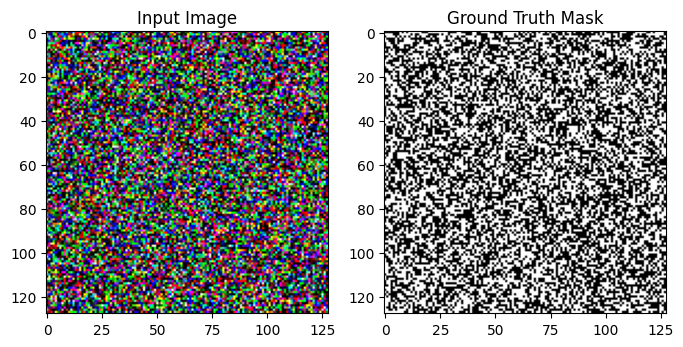

In [ ]:
import matplotlib.pyplot as plt
# 첫 번째 이미지를 시각화
sample_x = x[0]
sample_y = y[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_x.permute(1, 2, 0).numpy())
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(sample_y.squeeze().numpy(), cmap='gray')
plt.title('Ground Truth Mask')
plt.show()

## **모델 선언 및 학습**

In [ ]:
# --- 모델 선언 및 학습 ---
model = UNetSmall(upsample_mode='deconv', net_scaling=None, edge_crop=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# 간단히 30 epoch만
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6937
Epoch 2, Loss: 0.6932
Epoch 3, Loss: 0.6932
Epoch 4, Loss: 0.6932
Epoch 5, Loss: 0.6931
Epoch 6, Loss: 0.6932
Epoch 7, Loss: 0.6931
Epoch 8, Loss: 0.6931
Epoch 9, Loss: 0.6931
Epoch 10, Loss: 0.6930


## **아래 주석을 풀고 U-Net 모델에 대해 간단히 설명해주세요 😀**

[답변]


---

U-Net은 이미지 분할을 위한 합성곱 신경망으로 수축 경로와 확장 경로로 구성된다. 수축 경로에서 일반적인 합성곱층처럼 컨텍스트를 포착하고, 여기서 추출한 피처 맵을 확장 경로에서 업샘플링한 뒤, 수축 경로에서 포착한 특성 맵의 컨텍스트와 결합해 정확한 지역화를 수행한다.

1->64->128->256->512->1024

1024->512->256->128->64->1

다양한 크기의 특성 맵을 병합할 수 있도록 다운샘플링과 업샘플링을 위처럼 순서대로 반복한다. 그래서 확장 경로에서는 up-conv 합성곱을 사용한다.

## **아래 주석을 풀고 DeepLabv1, v2, v3. v3+  모델에 대해 각각 간단히 설명해주세요 🐶**

[답변]


---

DeepLab은 필터 내부에 빈 공간을 두는 Atrous 합성곱을 사용한다. 커널 픽셀 수는 유지해 파라미터 수를 늘리지 않으면서도 수용 영역을 확대해 특성을 찾는 범위를 늘릴 수 있다.

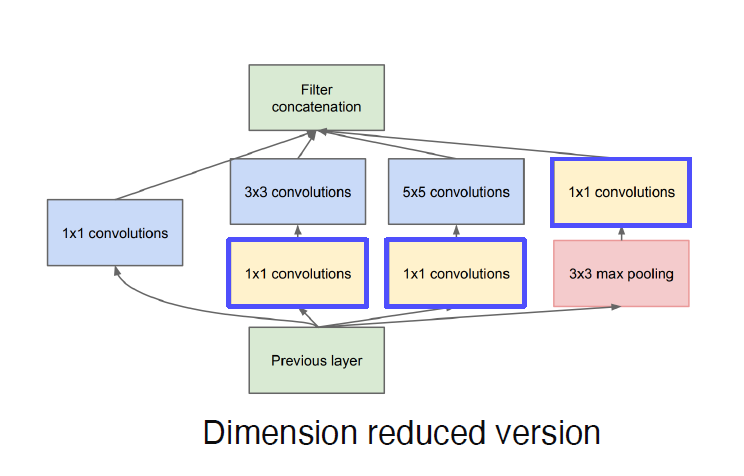

[DeepLab v1]

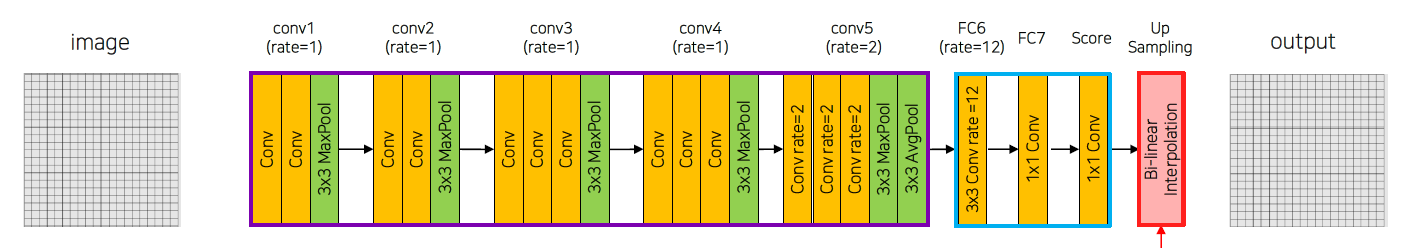

- Atrous Convolution을 사용해 피처 맵의 해상도를 줄이지 않고도 수용 영역을 확장해, 다운샘플링 없이 넓은 컨텍스트를 포함할 수 있도록 한 모델. 합성곱층 출력이 경계에서 무너지는 문제를 Conditional Random field를 적용해 해결하고자 했는데, CRF를 후처리 단계로 넣어서 속도가 느리고 멀티스케일에 약함.

[DeepLab v2]

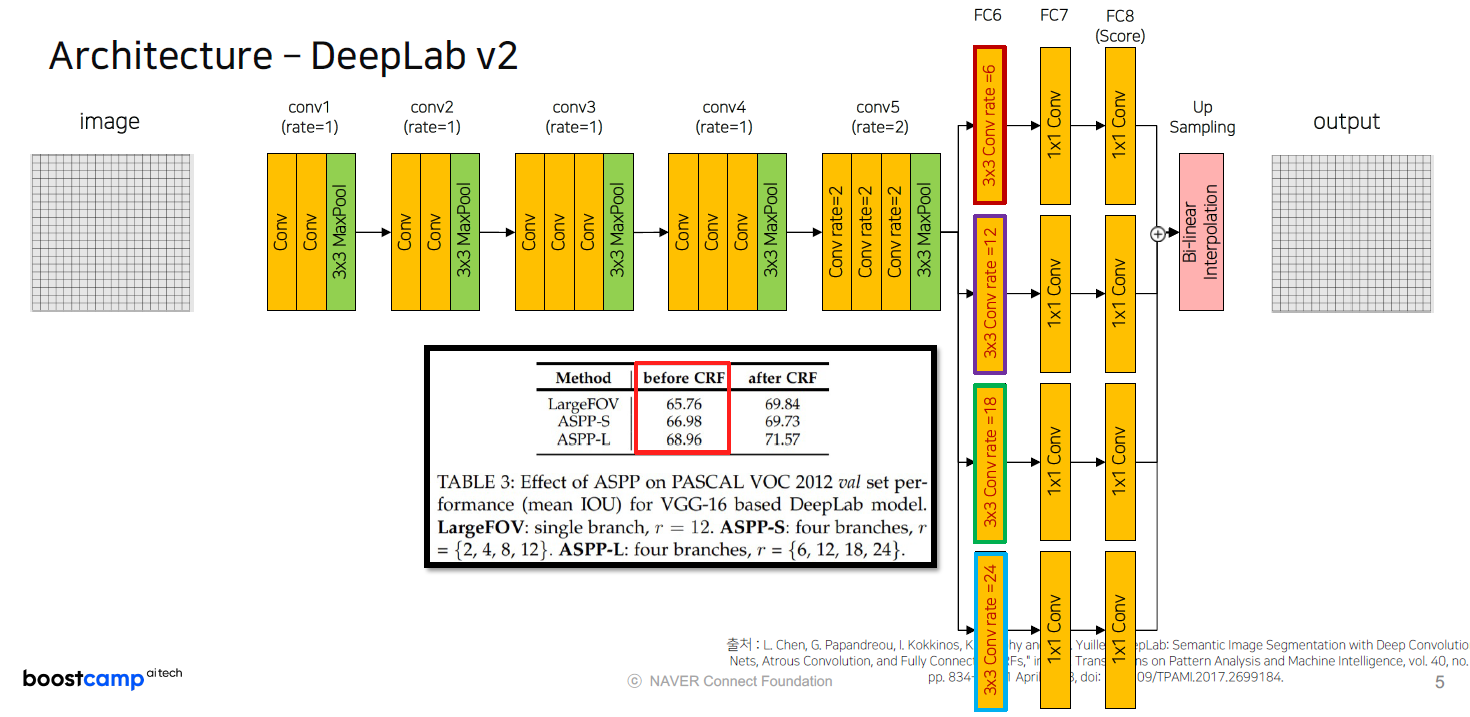

-합성곱의 빈 공간, 즉 rate로 여러 값을 사용함. 다양한 크기의 수용 영역을 형성하게 되면서 멀티스케일 문맥 정보를 동시에 학습할 수 있게 됨. 각 출력은 concatenate 후 1x1 conv로 통합함. CRF 때문에 속도가 느리고 구조가 복잡함.

[DeepLab v3]

- 더 다양한 rate를 사용해 컨텍스트 정보가 더 풍부해졌고, 1x1 conv branch와 global average pooling branch를 추가해 이미지 레벨 컨텍스트를 반영함. Batch normalization을 추가해 안정적인 학습이 가능해져서 CRF를 제거해 속도가 빨라짐. 단 픽셀 단위의 경계 복원력은 부족함.

[DeepLab v3+]

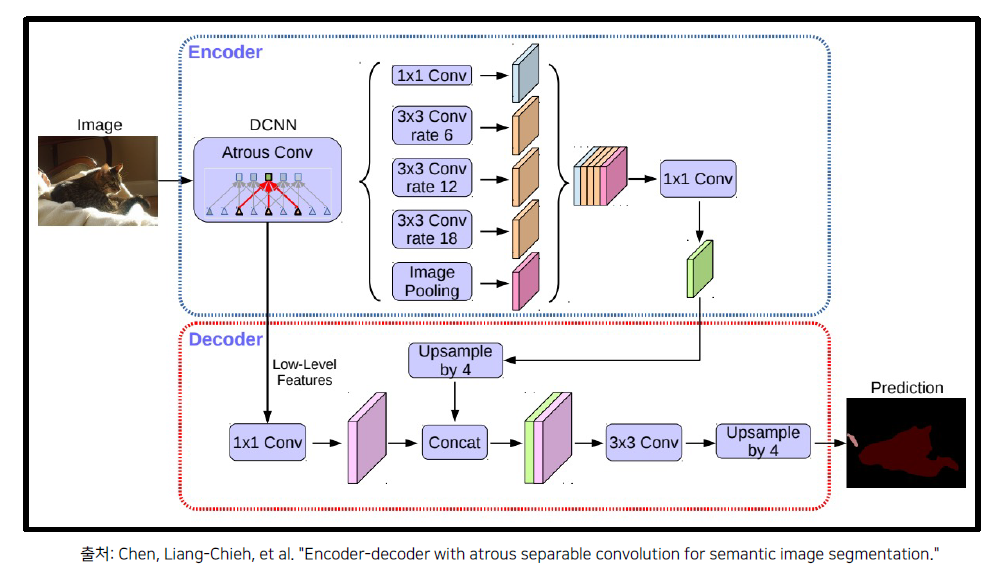

- 인코더-디코더 구조로 경계를 복원해 CRF를 사용하지 않으면서도 경계 복원 정확도가 향상됨. 인코더에서 추출한 특징을 디코더에서 받게 되면서 잃었던 공간 정보를 복원할 수 있는 것임. 인코더에서는 이전까지 썼던 구조 (backbone+ASPP)로 특징을 추출함.